# 2025/26 Artificial Intelligence (U19967) - Lab on Supervised Learning
        
#### Adedayo Olowolayemo, Msc AFHEA

## Today, we would be looking at Supervised Learning
## Using the Heart disease dataset, we would do the following

   ####   Load a dataset to use in this session
   ####   Clean the dataset and prepare it for use
   ####   Develop Gradient Boosting model
   ####   Train and test the model
   ####   Evaluate the model
   ####   Visualize and analyze the results
   ####   The goal is to develop supervised machine learning models 
   #### - such as Decision Trees, Random Forest, and Gradient Boosting—that learn from the dataset and can accurately predict      #### whether a patient is likely to develop heart disease.

#### N.B The Heart Disease dataset is available publicly and can be accessed from Kaggle or via the link https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset

# Step 1: Setting Up Our Tools

### Before we can do any real machine learning work, we need to bring in all the tools we’ll be using. Think of this step like opening your toolbox before fixing something we want everything we might need within reach.

#### Working with Data: NumPy and Pandas

In [2]:
import numpy as np   #numpy is needed to enable us work with numbers and any mathematical operations
import pandas as pd  #pandas is used for managing data in table form

# Visualizing Data: Matplotlib and Seaborn

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

### Both matplotlib and Seaborn help us to see what is happening in the data, you would remember from the Visual Data Analytics module that visualization is one of the most powerful step in understanding any dataset.

### Now we move to model preparation and evaluation tools from scikit-learn (sklearn). The below largely ensures we can train, tune, and test our models properly.


### Preparing and Testing Models

In [4]:

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, learning_curve

## Next we will import the core models to experiment with in today's lab.

### Tools for building models

In [5]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.dummy import DummyClassifier

### The last set of tools we need in this session are the ones for evaluating our models performances

## Evaluating Model Performance

In [6]:
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, RocCurveDisplay
)

### Having run/ executed the above code snippets, we should have our working environment ready for the complete machine learning process, from raw data to evaluated models.

# Step 2: Load and Explore the Data


### Now that we've set up all our tools, the next step is to load the dataset we'll be working with and take a first look at it. In this block of code, we're reading the data from a CSV file called “Heart.csv” using the Pandas library.


### The dataset will be stored in a DataFrame called df, which allows us to easily manipulate and explore it.



### We would also take a look at the first few rows of the dataset. This is a simple but powerful step: by viewing a small sample of the data, we can quickly verify that it looks the way we expect (that the columns have proper names, the values make sense, and there are no obvious issues like missing headers or formatting errors).


### In any data science or machine learning workflow, this initial inspection is essential. It gives us our first impression of the dataset and helps guide how we’ll clean, prepare, and analyze it in the next steps.

## 2a) Load the data

In [8]:
df = pd.read_csv("heart_data.csv") # df is the shorthand for dataframe
print("Raw shape:", df.shape)  # shows how many rows and columns the data contains
display(df.head()) # this would by default display the top 5 rows

Raw shape: (1025, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


## 2b) Visual EDA

C:\Users\user\AppData\Local\Temp\ipykernel_15988\1048974657.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette='Set2')   # remember 'sns' is the nickname for seaborn, the visualization tool we imported earlier on


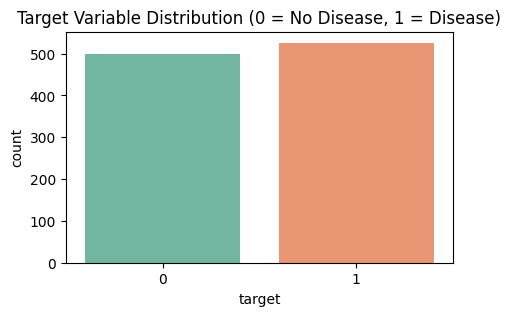

In [9]:
plt.figure(figsize=(5,3))
sns.countplot(x='target', data=df, palette='Set2')   # remember 'sns' is the nickname for seaborn, the visualization tool we imported earlier on
plt.title("Target Variable Distribution (0 = No Disease, 1 = Disease)")
plt.show()

### Following from the EDA visual code above, the next code section begins our initial exploration of the dataset's numerical features. After loading the data, it's essential to understand how each numeric variable behaves such as the variable's spread, shape, and possible outliers and this is exactly what this code helps us do.



### This block provides a quick visual summary of how each numerical variable is distributed. It helps us spot patterns, identify skewed or imbalanced data, and detect potential outliers early in the analysis.

## 2c) Numeric distributions

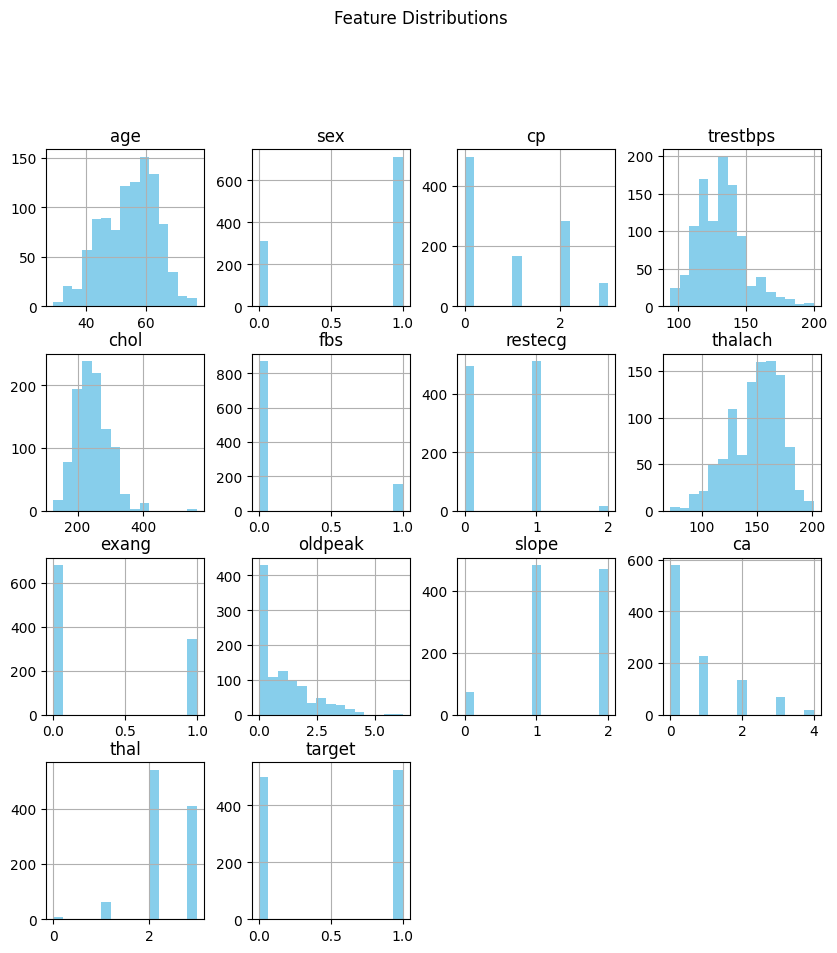

In [12]:
# Automatically select numerical columns
num_cols = df.select_dtypes(include='number').columns

# Now plot the histograms
df[num_cols].hist(figsize=(10,10), bins=15, color='skyblue')
plt.suptitle("Feature Distributions", y=1.02)
plt.show()


### The above grid of histograms (one for each numerical feature in the Heart dataset) shows that most of the continuous features follow reasonable distributions for clinical data, while the categorical ones appear properly encoded for machine learning use. This step helps us understand the shape and nature of the data, guiding us in preprocessing and choosing suitable algorithms for modeling later on.

### From a quick look, we can observe that the age, trestbps (resting blood pressure), chol (cholesterol), and thalach (maximum heart rate) columns all display roughly bell-shaped distributions, though they are slightly skewed to one side. This suggests that most patients in the dataset fall within a common middle range for these physiological measurements, with fewer individuals at the extremes.

### We can also visualize the relationships between different numerical variables in the dataset using a correlation heatmap. After exploring how each feature behaves individually, it is useful to understand how they interact with one another - whether some features tend to rise or fall together, or if some are largely independent.

## 2d) Correlation heatmap

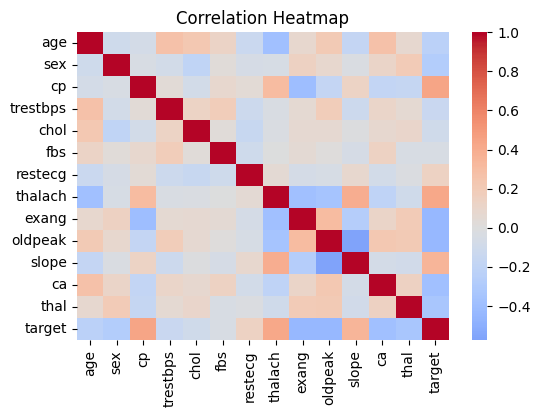

In [13]:
plt.figure(figsize=(6,4))  #creates a new plotting area and sets its size

corr = df.corr(numeric_only=True)  # calculates the correlation matrix for all numeric columns in the dataset.
                                   # Each value in this matrix represents the strength and direction of a linear relationship between two variables.
                                   # A correlation close to +1 means that the two features increase together,
                                   # a value close to –1 means that one decreases when the other increases, and a value near zero indicates no meaningful linear relationship.

sns.heatmap(corr, cmap='coolwarm', center=0, annot=False) # Here we use Seaborn to display the correlation matrix visually.
plt.title("Correlation Heatmap")
plt.show()

### This final piece of the data loading and preprocessing step takes the correlation analysis one step further by focusing on the features that are most strongly related to the target variable, which represents the presence or absence of heart disease.

### The goal here is to visually explore how these top features interact with one another and with the target, helping us understand which variables might be the most influential predictors.

## 2e) Pairplot for top correlated features

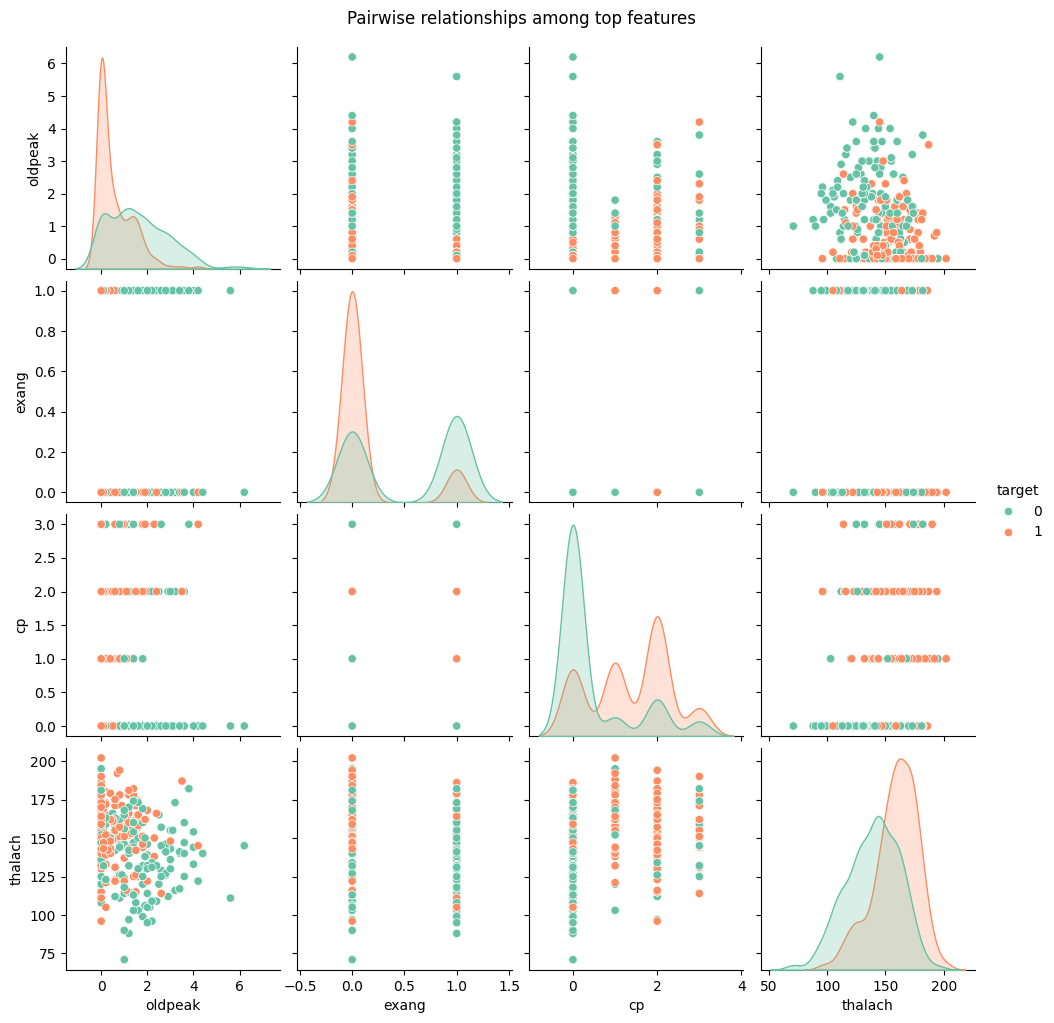

In [14]:
top_corr = corr['target'].abs().sort_values(ascending=False)[1:5].index.tolist()  # selects the four features that have the strongest absolute correlation with the target variable.
                                                                                  # The code takes the correlation values between every feature and target, converts them to absolute values
                                                                                  # so that both positive and negative relationships are treated equally, sorts them in descending order,
                                                                                  # and then picks the top four (excluding the target itself, which would always have a perfect correlation of 1.0).


sns.pairplot(df[top_corr + ['target']], hue='target', diag_kind='kde', palette='Set2')  # here, we are using Seaborn’s pairplot function to create a grid of scatterplots
                                                                                        # showing how these top features relate to one another.
plt.suptitle("Pairwise relationships among top features", y=1.02)
plt.show()

# Step 3: Train/Test Split (Stratified)

### This section marks the beginning of the model preparation phase, where we split the dataset into training and testing subsets. The goal here is to create two separate portions of the data: one for training the machine learning model and another for testing its performance on unseen examples. This separation is fundamental because it allows us to evaluate how well the model generalizes, rather than just how well it memorizes the data it has already seen.

In [15]:
#  Train/Test Split (Stratified)

X = df.drop('target', axis=1)   #) divide the dataset into features (X) and the target variable (y)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.35, stratify=y, random_state=42
)
print("\nTrain size:", X_train.shape, " Test size:", X_test.shape)
print("Train target balance:\n", y_train.value_counts(normalize=True))


Train size: (666, 13)  Test size: (359, 13)
Train target balance:
 target
1    0.513514
0    0.486486
Name: proportion, dtype: float64


# Step 4: Baselines & Gradient Boosting

### You will see in the below the different models we would be considering in this session.

### The DummyClassifier serves as a baseline model - it doesn't actually learn any patterns from the data but simply predicts the most frequent class. This gives us a performance reference point: any real model should do better than the dummy.


### The DecisionTreeClassifier is a simple, interpretable model that splits the data based on feature thresholds to make predictions.

### The RandomForestClassifier improves on this by combining multiple decision trees into an ensemble, which typically increases accuracy and stability.

### Lastly, the GradientBoostingClassifier builds trees sequentially, with each new tree correcting the errors made by the previous ones, often resulting in strong predictive performance.

#### N.B The same random_state 42 is used for all the models

In [16]:
models = {
    "Dummy": DummyClassifier(strategy="most_frequent", random_state=42),
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42),
    "GBoost": GradientBoostingClassifier(random_state=42)
}


def evaluate(name, model):
    """Fit on train, evaluate on test, return metrics."""
    model.fit(X_train, y_train)  #this line of our code is for fitting our model on the training data (i.e making the model learn from known examples)
    preds = model.predict(X_test) #this would now generate predictions based on the unseen data
    proba = model.predict_proba(X_test)[:,1] if hasattr(model, "predict_proba") else None
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    auc = roc_auc_score(y_test, proba) if proba is not None else np.nan
    print(f"\n{name}")
    print(f"Accuracy: {acc:.3f} | F1: {f1:.3f} | ROC-AUC: {auc:.3f}")
    print("Confusion Matrix:\n", confusion_matrix(y_test, preds))
    return acc, f1, auc, model

results = {n: evaluate(n, m) for n, m in models.items()}  #here we evaluate function for each model in the dictionary


Dummy
Accuracy: 0.513 | F1: 0.678 | ROC-AUC: 0.500
Confusion Matrix:
 [[  0 175]
 [  0 184]]

DecisionTree
Accuracy: 0.975 | F1: 0.975 | ROC-AUC: 0.976
Confusion Matrix:
 [[175   0]
 [  9 175]]

RandomForest
Accuracy: 0.983 | F1: 0.983 | ROC-AUC: 0.998
Confusion Matrix:
 [[175   0]
 [  6 178]]

GBoost
Accuracy: 0.983 | F1: 0.984 | ROC-AUC: 0.984
Confusion Matrix:
 [[172   3]
 [  3 181]]


####  In the results above, you woukld see the Accuracy, F1-Score, and theROC-AUC.

####  Also confusion matrix for each of the models we worked with. The confusion matrix shows the TP, FP, TN, and FN. 

## ROC Curve for Gradient Boosting (Default)

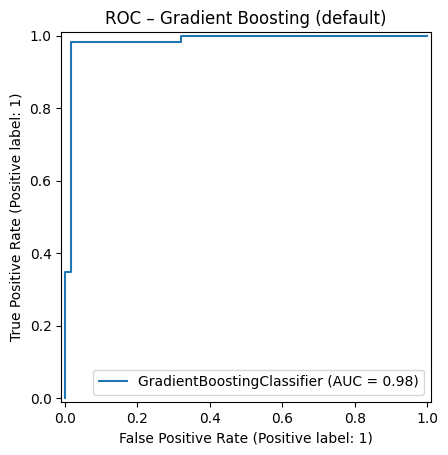

In [17]:
gb_default = models["GBoost"]
RocCurveDisplay.from_estimator(gb_default, X_test, y_test)
plt.title("ROC – Gradient Boosting (default)")
plt.show()

In [18]:
# Light Hyperparameter Tuning


gb = GradientBoostingClassifier(random_state=42)
grid = {'n_estimators':[100, 150, 200, 250, 400], 'learning_rate':[0.01, 0.1]}
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

search = GridSearchCV(gb, grid, cv=cv, scoring='roc_auc', n_jobs=-1)
search.fit(X_train, y_train)
print("\nBest parameters:", search.best_params_)
print("Best cross-validated ROC-AUC:", round(search.best_score_, 3))

gb_best = search.best_estimator_
acc, f1, auc, _ = evaluate("GBoost (tuned)", gb_best)


Best parameters: {'learning_rate': 0.1, 'n_estimators': 200}
Best cross-validated ROC-AUC: 0.99

GBoost (tuned)
Accuracy: 0.983 | F1: 0.984 | ROC-AUC: 0.993
Confusion Matrix:
 [[172   3]
 [  3 181]]


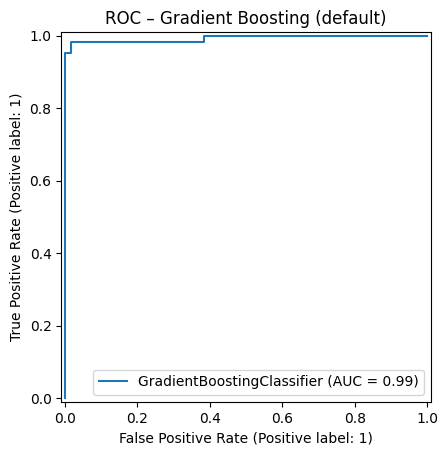

In [26]:
RocCurveDisplay.from_estimator(gb_best, X_test, y_test)
plt.title("ROC – Gradient Boosting (default)")
plt.show()

## Comparative Performance Visuals

In [19]:
# Collect metrics for all models
metrics_df = pd.DataFrame([
    {"Model": name,
     "Accuracy": vals[0],
     "F1": vals[1],
     "ROC_AUC": vals[2]} for name, vals in results.items()
])
metrics_df = pd.concat([
    metrics_df,
    pd.DataFrame([{"Model":"GBoost (tuned)", "Accuracy":acc, "F1":f1, "ROC_AUC":auc}])
], ignore_index=True)

print("\nModel Performance Summary:")
display(metrics_df)


Model Performance Summary:


,Model,Accuracy,F1,ROC_AUC
0,Dummy,0.512535,0.677716,0.500000
1,DecisionTree,0.974930,0.974930,0.975543
2,RandomForest,0.983287,0.983425,0.998090
3,GBoost,0.983287,0.983696,0.983882
4,GBoost (tuned),0.983287,0.983696,0.993199


### Bar plot comparison

C:\Users\user\AppData\Local\Temp\ipykernel_15988\3033746329.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y="ROC_AUC", data=metrics_df, palette="viridis")


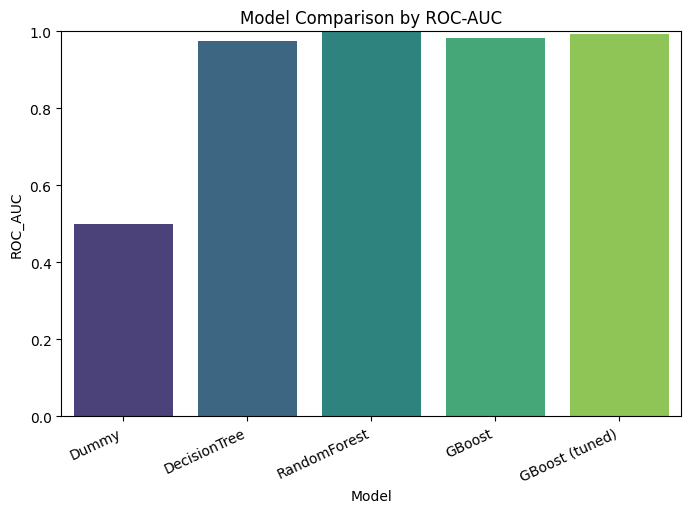

In [21]:
plt.figure(figsize=(8,5))
sns.barplot(x="Model", y="ROC_AUC", data=metrics_df, palette="viridis")
plt.title("Model Comparison by ROC-AUC")
plt.ylim(0,1)
plt.xticks(rotation=25, ha='right')
plt.show()

### Parallel bar chart for multiple metrics

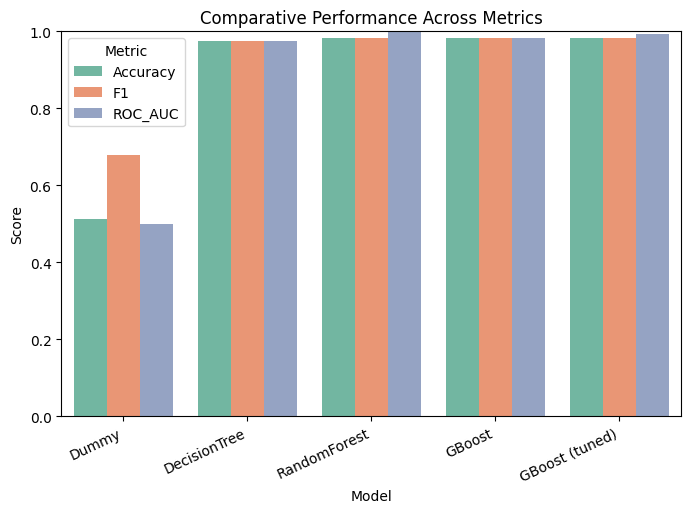

In [22]:
metrics_df_melted = metrics_df.melt(id_vars="Model", var_name="Metric", value_name="Score")
plt.figure(figsize=(8,5))
sns.barplot(x="Model", y="Score", hue="Metric", data=metrics_df_melted, palette="Set2")
plt.title("Comparative Performance Across Metrics")
plt.xticks(rotation=25, ha='right')
plt.ylim(0,1)
plt.show()

### Learning Curve (Bias/Variance)

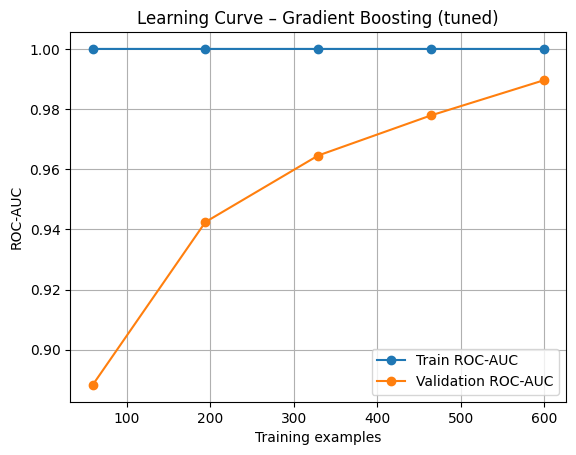

In [23]:
train_sizes, train_scores, val_scores = learning_curve(
    gb_best, X_train, y_train, cv=cv, scoring='roc_auc',
    train_sizes=np.linspace(0.1, 1.0, 5), n_jobs=-1
)
plt.plot(train_sizes, train_scores.mean(axis=1), 'o-', label='Train ROC-AUC')
plt.plot(train_sizes, val_scores.mean(axis=1), 'o-', label='Validation ROC-AUC')
plt.xlabel("Training examples"); plt.ylabel("ROC-AUC")
plt.title("Learning Curve – Gradient Boosting (tuned)")
plt.legend(); plt.grid(True); plt.show()

### Feature Importances


Top 10 features by importance:
 cp          0.314357
ca          0.126532
oldpeak     0.117875
age         0.094450
thal        0.083992
chol        0.064606
thalach     0.062590
sex         0.043061
trestbps    0.037729
exang       0.024970
dtype: float64


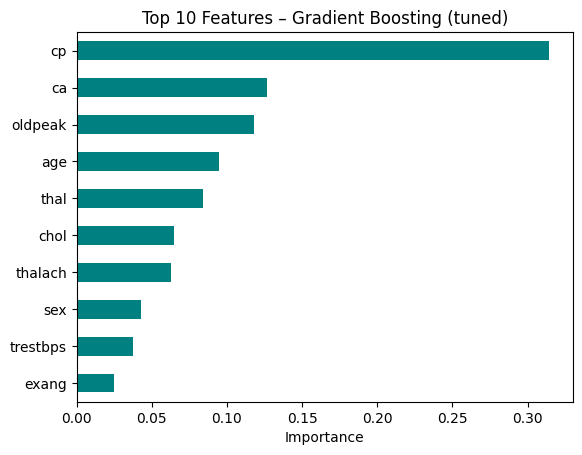

In [24]:
imp = pd.Series(gb_best.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nTop 10 features by importance:\n", imp.head(10))
imp.head(10).plot(kind='barh', color='teal')
plt.gca().invert_yaxis()
plt.title("Top 10 Features – Gradient Boosting (tuned)")
plt.xlabel("Importance")
plt.show()

# Some links for you

https://www.wseas.com/journals/bab/2022/a025108-001(2022).pdf

https://www.geeksforgeeks.org/machine-learning/ml-dummy-classifiers-using-sklearn/

https://repository.canterbury.ac.uk/item/9753x/cancer-investigating-the-impact-of-the-implementation-platform-on-machine-learning-models

# Exercise 1

From the hyperparameter tunning code sniippet above, vary the n_estimator in your GBoost Model and observe the impact on 

1) Accuracy, and F1 Score metrics
2) How the confusion matrix vary, and

when;

n_estimators are 50, 100, 500, 1000

# Exercise 2

Earleir on, we used Train_test split of 65:35.  You should now attempt to vary this by using a Train_test split of;
    
    80:20
    70:30
    60:40

Observe and record the accuracy metrics of the  - (a) all the models 
                                                  (b) Gboost (tuned)

In [27]:
gb = GradientBoostingClassifier(random_state=42)
grid = {'n_estimators':[100], 'learning_rate':[0.01, 0.1]}
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

search = GridSearchCV(gb, grid, cv=cv, scoring='roc_auc', n_jobs=-1)
search.fit(X_train, y_train)
print("\nBest parameters:", search.best_params_)
print("Best cross-validated ROC-AUC:", round(search.best_score_, 3))

gb_best = search.best_estimator_
acc, f1, auc, _ = evaluate("GBoost (tuned)", gb_best)


Best parameters: {'learning_rate': 0.1, 'n_estimators': 100}
Best cross-validated ROC-AUC: 0.989

GBoost (tuned)
Accuracy: 0.983 | F1: 0.984 | ROC-AUC: 0.984
Confusion Matrix:
 [[172   3]
 [  3 181]]


In [28]:
gb = GradientBoostingClassifier(random_state=42)
grid = {'n_estimators':[150], 'learning_rate':[0.01, 0.1]}
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

search = GridSearchCV(gb, grid, cv=cv, scoring='roc_auc', n_jobs=-1)
search.fit(X_train, y_train)
print("\nBest parameters:", search.best_params_)
print("Best cross-validated ROC-AUC:", round(search.best_score_, 3))

gb_best = search.best_estimator_
acc, f1, auc, _ = evaluate("GBoost (tuned)", gb_best)


Best parameters: {'learning_rate': 0.1, 'n_estimators': 150}
Best cross-validated ROC-AUC: 0.99

GBoost (tuned)
Accuracy: 0.975 | F1: 0.976 | ROC-AUC: 0.986
Confusion Matrix:
 [[169   6]
 [  3 181]]


In [29]:
gb = GradientBoostingClassifier(random_state=42)
grid = {'n_estimators':[200], 'learning_rate':[0.01, 0.1]}
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

search = GridSearchCV(gb, grid, cv=cv, scoring='roc_auc', n_jobs=-1)
search.fit(X_train, y_train)
print("\nBest parameters:", search.best_params_)
print("Best cross-validated ROC-AUC:", round(search.best_score_, 3))

gb_best = search.best_estimator_
acc, f1, auc, _ = evaluate("GBoost (tuned)", gb_best)


Best parameters: {'learning_rate': 0.1, 'n_estimators': 200}
Best cross-validated ROC-AUC: 0.99

GBoost (tuned)
Accuracy: 0.983 | F1: 0.984 | ROC-AUC: 0.993
Confusion Matrix:
 [[172   3]
 [  3 181]]


In [30]:
gb = GradientBoostingClassifier(random_state=42)
grid = {'n_estimators':[250], 'learning_rate':[0.01, 0.1]}
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

search = GridSearchCV(gb, grid, cv=cv, scoring='roc_auc', n_jobs=-1)
search.fit(X_train, y_train)
print("\nBest parameters:", search.best_params_)
print("Best cross-validated ROC-AUC:", round(search.best_score_, 3))

gb_best = search.best_estimator_
acc, f1, auc, _ = evaluate("GBoost (tuned)", gb_best)


Best parameters: {'learning_rate': 0.1, 'n_estimators': 250}
Best cross-validated ROC-AUC: 0.99

GBoost (tuned)
Accuracy: 0.975 | F1: 0.976 | ROC-AUC: 0.994
Confusion Matrix:
 [[169   6]
 [  3 181]]


In [31]:
gb = GradientBoostingClassifier(random_state=42)
grid = {'n_estimators':[400], 'learning_rate':[0.01, 0.1]}
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

search = GridSearchCV(gb, grid, cv=cv, scoring='roc_auc', n_jobs=-1)
search.fit(X_train, y_train)
print("\nBest parameters:", search.best_params_)
print("Best cross-validated ROC-AUC:", round(search.best_score_, 3))

gb_best = search.best_estimator_
acc, f1, auc, _ = evaluate("GBoost (tuned)", gb_best)


Best parameters: {'learning_rate': 0.1, 'n_estimators': 400}
Best cross-validated ROC-AUC: 0.99

GBoost (tuned)
Accuracy: 0.983 | F1: 0.984 | ROC-AUC: 0.993
Confusion Matrix:
 [[172   3]
 [  3 181]]


In [32]:
gb = GradientBoostingClassifier(random_state=42)
grid = {'n_estimators':[50], 'learning_rate':[0.01, 0.1]}
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

search = GridSearchCV(gb, grid, cv=cv, scoring='roc_auc', n_jobs=-1)
search.fit(X_train, y_train)
print("\nBest parameters:", search.best_params_)
print("Best cross-validated ROC-AUC:", round(search.best_score_, 3))

gb_best = search.best_estimator_
acc, f1, auc, _ = evaluate("GBoost (tuned)", gb_best)


Best parameters: {'learning_rate': 0.1, 'n_estimators': 50}
Best cross-validated ROC-AUC: 0.976

GBoost (tuned)
Accuracy: 0.950 | F1: 0.952 | ROC-AUC: 0.978
Confusion Matrix:
 [[164  11]
 [  7 177]]


In [33]:
gb = GradientBoostingClassifier(random_state=42)
grid = {'n_estimators':[1000], 'learning_rate':[0.01, 0.1]}
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

search = GridSearchCV(gb, grid, cv=cv, scoring='roc_auc', n_jobs=-1)
search.fit(X_train, y_train)
print("\nBest parameters:", search.best_params_)
print("Best cross-validated ROC-AUC:", round(search.best_score_, 3))

gb_best = search.best_estimator_
acc, f1, auc, _ = evaluate("GBoost (tuned)", gb_best)


Best parameters: {'learning_rate': 0.1, 'n_estimators': 1000}
Best cross-validated ROC-AUC: 0.991

GBoost (tuned)
Accuracy: 0.981 | F1: 0.981 | ROC-AUC: 0.994
Confusion Matrix:
 [[171   4]
 [  3 181]]
